<h1 style = "color : #0EE071; text-align : center;"><em>Nata Project</em> - Feature Management Notebook</h1>
<p style = "font-size : 16px; text-align: center;">This notebook has the funcion of preparing the features for the learning model.</p>
<br>
<p style = "font-size : 12px; text-align: center;"><b>NOVA IMS</b></p>
<p style = "font-size : 10px; text-align: center;">Machine Learning I</p>
<p style = "font-size : 10px; text-align: center;">Group 08: Diogo Gonçalves, João Marques, Juan Mendes, Gustavo Franco & Lucas Casimiro</p>
<br>


## <a class="anchor" id="0th-bullet">Table of Contents</a>


* [<b>1. Imports & Dataset Loading</b>](#1st-bullet)<br>

* [<b>2. Feature Construction</b>](#2nd-bullet)<br>
    * [2.1 Baking Intensity](#3rd-bullet)<br>
    * [2.2 Sugar per Egg Yolk](#4th-bullet)<br>

* [<b>3. Feature Scaling</b>](#5th-bullet)<br>
    
    
* [<b>4. Feature Selection</b>](#6th-bullet)<br>
    * [4.1 Handling Multicolinearity](#7th-bullet)<br>
    * [4.2 Filter methods](#8th-bullet)<br>
        * [4.2.1 Constant features](#9th-bullet)<br>
        * [4.2.2 Spearman Correlation](#10th-bullet)<br>
    * [4.3 Wrapper Methods](#11th-bullet)<br>
        * [4.3.1 RFE](#12th-bullet)<br>
    * [4.4 Embedded Methods](#12th-bullet)<br>
        * [4.4.1 Lasso Regression](#13th-bullet)<br>
        * [4.4.2 Decision Tree](#14th-bullet)<br>
    * [4.5 Final Insights](#15th-bullet)<br>

* [<b>5. Exports</b>](#16th-bullet)<br>




<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 1. Imports & Dataset Loading</h2>

In [23]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

In [24]:
X_train = pd.read_pickle('Nata_files/data_clean/X_train_clean.pkl')
X_test = pd.read_pickle('Nata_files/data_clean/X_test_clean.pkl')
y_train = pd.read_pickle('Nata_files/data_clean/y_train_clean.pkl')
y_test = pd.read_pickle('Nata_files/data_clean/y_test_clean.pkl')

<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 2. Feature Construction</h2>
<p style = "font-size : 15px;">In order to unlock some potential that some features may have, but is incomplete, we should try to build more features using both domian knowledge and conclusions from previous analysis. After this, we will have the opportunity to access if these are, or not good features.</p>

<h3  style = "color : #0EE071;"> 2.1. Baking Intensity</h3>

<p>In this dataset, we already have a feature called <code>baking_duration</code>, that is the time the pastel de nata was in the oven, and another called <code>final_temperature</code> that is the temperature in which the oven was at the end of the baking. If we combine these two, by multiplcation, we get a number for the intensity that combines both temperature and time (major aspects of how a pastry comes out of an oven).</p>

In [25]:
X_train['baking_intensity'] = X_train['baking_duration'] * X_train['oven_temperature']
X_test['baking_intensity'] = X_test['baking_duration'] * X_test['oven_temperature']

<h3  style = "color : #0EE071;"> 2.2. Sugar per Egg Yolk</h3>

<p>From a very reliable domain knowledge source - our grandmas - we know that a very important aspect of how a Pastel de Nata comes out of an oven is related to the amout of sugar per egg yolk, this is why we are now creating a feature that divides <code>sugar_content</code> and <code>egg_yolk_count</code>, and later lets access if this piece of domain knowledge is useful.</p>

In [26]:
X_train['sugar_per_egg'] = X_train['sugar_content'] / X_train['egg_yolk_count']
X_test['sugar_per_egg'] = X_test['sugar_content'] / X_test['egg_yolk_count']

<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 3. Feature Scaling</h2>
<p style = "font-size : 15px;">To optimize our model, we must address the different scales and distributions of our data. In this section, we apply Robust Scaling. This prevents features with larger magnitudes from dominating the model's learning process.</p>

In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4157 entries, 893 to 4904
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ambient_humidity   4157 non-null   float64
 1   baking_duration    4157 non-null   float64
 2   cooling_period     4157 non-null   float64
 3   cream_fat_content  4157 non-null   float64
 4   egg_temperature    4157 non-null   float64
 5   egg_yolk_count     4157 non-null   float64
 6   final_temperature  4157 non-null   float64
 7   lemon_zest_ph      4157 non-null   float64
 8   oven_temperature   4157 non-null   float64
 9   preheating_time    4157 non-null   float64
 10  salt_ratio         4157 non-null   float64
 11  sugar_content      4157 non-null   float64
 12  vanilla_extract    4157 non-null   float64
 13  origin_porto       4157 non-null   int64  
 14  baking_intensity   4157 non-null   float64
 15  sugar_per_egg      4157 non-null   float64
dtypes: float64(15), int64(1)
me

<p>Standard scaling methods (such as StandardScaler) rely on the mean and standard deviation. If the data has outliers like the high-income values we saw previously, the mean gets pulled towards them, compressing the majority of normal data into a tiny range.</p>
<p>RobustScaler uses the Median and the Interquartile Range (IQR). It centers the data around the median and scales it based on the middle 50% of the data. This effectively "shrinks" the extreme outliers without letting them ruin the distribution of the normal data, ensuring our model learns from the core patterns rather than the exceptions.</p>

The dataset has no categorical variables (as defined in Pandas), but we know that <code>origin_porto</code> works like a categorical variable '1' means origin is Porto // '0' means origin is Lisbon, so we have to filter the purely numerical features.
<br>
Also, regarding <code>egg_yolk_count</code> that is a discreet feature with a small finite range (e.g., 8 to 15), so we will also leave this feature at its original form:

In [28]:
# Degining numerical columns to scale
features_to_scale = ['ambient_humidity', 'baking_duration', 'cooling_period', 'cream_fat_content', 'egg_temperature',
                     'final_temperature', 'lemon_zest_ph', 'oven_temperature', 'preheating_time', 'salt_ratio',
                     'sugar_content', 'vanilla_extract', 'baking_intensity', 'sugar_per_egg'] 

# Defining the scaler
scaler = RobustScaler()

# Creating copies of the original data
X_train_scl = X_train.copy()
X_test_scl = X_test.copy()

# Fitting only the training data
X_train_scl[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])

# Transforming the test and train data:
X_train_scl[features_to_scale] = scaler.transform(X_train[features_to_scale])
X_test_scl[features_to_scale] = scaler.transform(X_test[features_to_scale])


In [29]:
X_train_scl.head()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto,baking_intensity,sugar_per_egg
893,0.45,1.444444,0.000000,0.000000,0.107143,10.0,-0.643478,0.0,-0.720721,2.575,2.031878,0.059524,0.764706,1,0.030116,0.056468
1033,0.75,-0.444444,-0.285714,-0.333333,0.000000,10.0,0.478261,-0.5,0.369369,0.400,0.469629,0.000000,-1.117647,0,0.050308,0.000000
4706,-0.65,0.444444,-0.142857,0.666667,1.107143,14.0,-0.243478,0.0,-0.144144,-0.200,-0.603163,0.071429,0.294118,0,0.215606,-0.642124
3072,0.05,0.444444,0.428571,0.200000,-0.785714,12.0,-0.556522,0.5,-0.495495,-1.400,-0.884287,-1.107143,-0.705882,0,-0.171458,-1.278063
4016,0.80,1.666667,-1.071429,0.000000,-0.928571,9.0,-0.556522,0.0,-0.603604,0.825,1.354167,0.142857,-0.294118,0,0.308008,0.419119


In [30]:
X_test_scl.head()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto,baking_intensity,sugar_per_egg
2642,0.20,1.000000,1.928571,0.400000,0.000000,9.0,0.000000,-0.5,0.000000,0.050,1.754267,0.000000,-0.529412,0,0.761123,0.268538
2789,-0.50,0.000000,1.714286,0.000000,0.000000,9.0,1.400000,-1.5,0.000000,0.450,0.409890,0.000000,0.235294,0,0.065024,0.268538
595,0.50,-0.111111,0.428571,0.533333,0.000000,10.0,1.356522,0.0,1.324324,-0.375,0.104669,0.000000,-0.294118,0,1.195072,0.000000
2010,0.65,-0.333333,0.214286,0.666667,1.357143,12.0,-0.034783,1.0,-0.126126,-0.600,-0.319026,0.214286,-0.352941,0,-0.272416,-0.233402
3229,-0.65,0.888889,-2.214286,0.333333,0.035714,11.0,-0.991304,1.5,-0.990991,-0.725,1.512801,-0.285714,0.176471,1,-0.558522,-0.466119


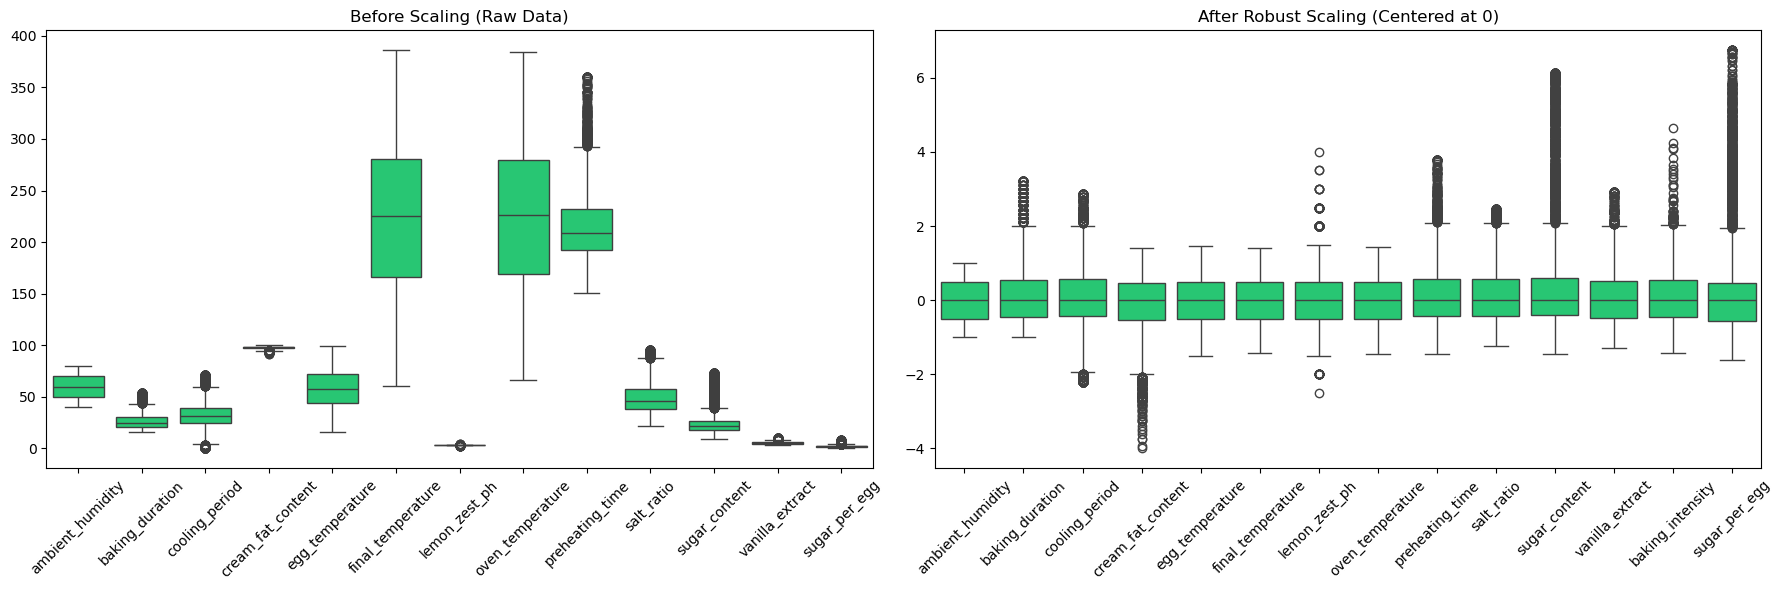

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# We have to take 'baking_intensity' from this list, so that we can plot (as much condensed) these features, compare them, and ensure scaling is not destroy
# by 'baking_intensity'
features_to_scale_2 = ['ambient_humidity', 'baking_duration', 'cooling_period', 'cream_fat_content', 'egg_temperature',
                     'final_temperature', 'lemon_zest_ph', 'oven_temperature', 'preheating_time', 'salt_ratio',
                     'sugar_content', 'vanilla_extract', 'sugar_per_egg'] 

# 1. Plot Original Data (Only the continuous features)
sns.boxplot(data=X_train[features_to_scale_2], ax=axes[0], color='#0EE071')
axes[0].set_title('Before Scaling (Raw Data)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Plot Scaled Data
sns.boxplot(data=X_train_scl[features_to_scale], ax=axes[1], color='#0EE071')
axes[1].set_title('After Robust Scaling (Centered at 0)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 4. Feature Selection</h2>

<h3 style="color: #0EE071;">4.1 Handling Multicolinearity</h3>


As seen in the correlation heatmap in NB1, we see, for example, that <code>oven_temperature</code> and <code>final_temperature</code> have an extremely high correlation, which means having both is redundant, so we will check for their correlation with the target variable and make a decision to drop the one with the lowest value before getting into the filter methods.

In [32]:
# Correlation analysis before dropping features
analysis_corr = pd.DataFrame(X_train_scl, columns=X_train.columns)[['oven_temperature', 'final_temperature']].copy()
analysis_corr['quality_class'] = y_train.values

corr_oven = analysis_corr['oven_temperature'].corr(analysis_corr['quality_class'])
corr_final = analysis_corr['final_temperature'].corr(analysis_corr['quality_class'])

print(f"Correlation (Oven Temp vs Target): {corr_oven}")
print(f"Correlation (Final Temp vs Target): {corr_final}")


Correlation (Oven Temp vs Target): -0.043876851948513707
Correlation (Final Temp vs Target): -0.04347796497722893


We conclude that the 'final_temperature' column has a higher absolute correlation, which means it has a better chance of helping to predict the target variable. So, we will drop 'oven_temperature'.

In [33]:
X_train.drop('oven_temperature', axis=1, inplace=True)
X_test.drop('oven_temperature', axis=1, inplace=True)

X_train_scl.drop('oven_temperature', axis=1, inplace=True)
X_test_scl.drop('oven_temperature', axis=1, inplace=True)

NOTE: We are aware that the correlation values don't match the justification given above for dropping 'oven_temperature'. This is because slight changes were made in the preprocessing phase while trying to obtain better results for the Kaggle submission. 

We found this error after the Kaggle deadline. We decided to keep it, as the difference is very minimal, and we believed it was better to maintain the predictions submitted on the competition.

<h3 style="color: #0EE071;">4.2 Filter methods</h3>

<h4 style="color: #0EE071;">4.2.1 Constant Features</h4>

In [34]:
X_train_scl.var().sort_values()

origin_porto         0.179064
ambient_humidity     0.334618
final_temperature    0.499391
egg_temperature      0.531204
baking_intensity     0.555869
vanilla_extract      0.671034
lemon_zest_ph        0.678345
salt_ratio           0.743294
baking_duration      0.792154
cream_fat_content    0.795610
preheating_time      0.879926
cooling_period       1.023423
egg_yolk_count       1.584989
sugar_per_egg        2.776107
sugar_content        3.278659
dtype: float64

<p>We conclude that all variables in the dataset exhibit non-zero variance, indicating diversity and variability in their values, so no measures need to be taken.</p>
<p>To note that <code>origin_porto</code> has a remarkebly low variace (as expected, as there are only 2 categories for 'origin').</p>

<h4 style="color: #0EE071;">4.2.2 Spearman Correlation</h4>

We will now examine the Spearman correlation between variables.  To facilitate this analysis, a new dataframe has been created using all the training data, including the dependent variable. This inclusion allows us to investigate whether any of the independent variables exhibit correlations with the target variable. 



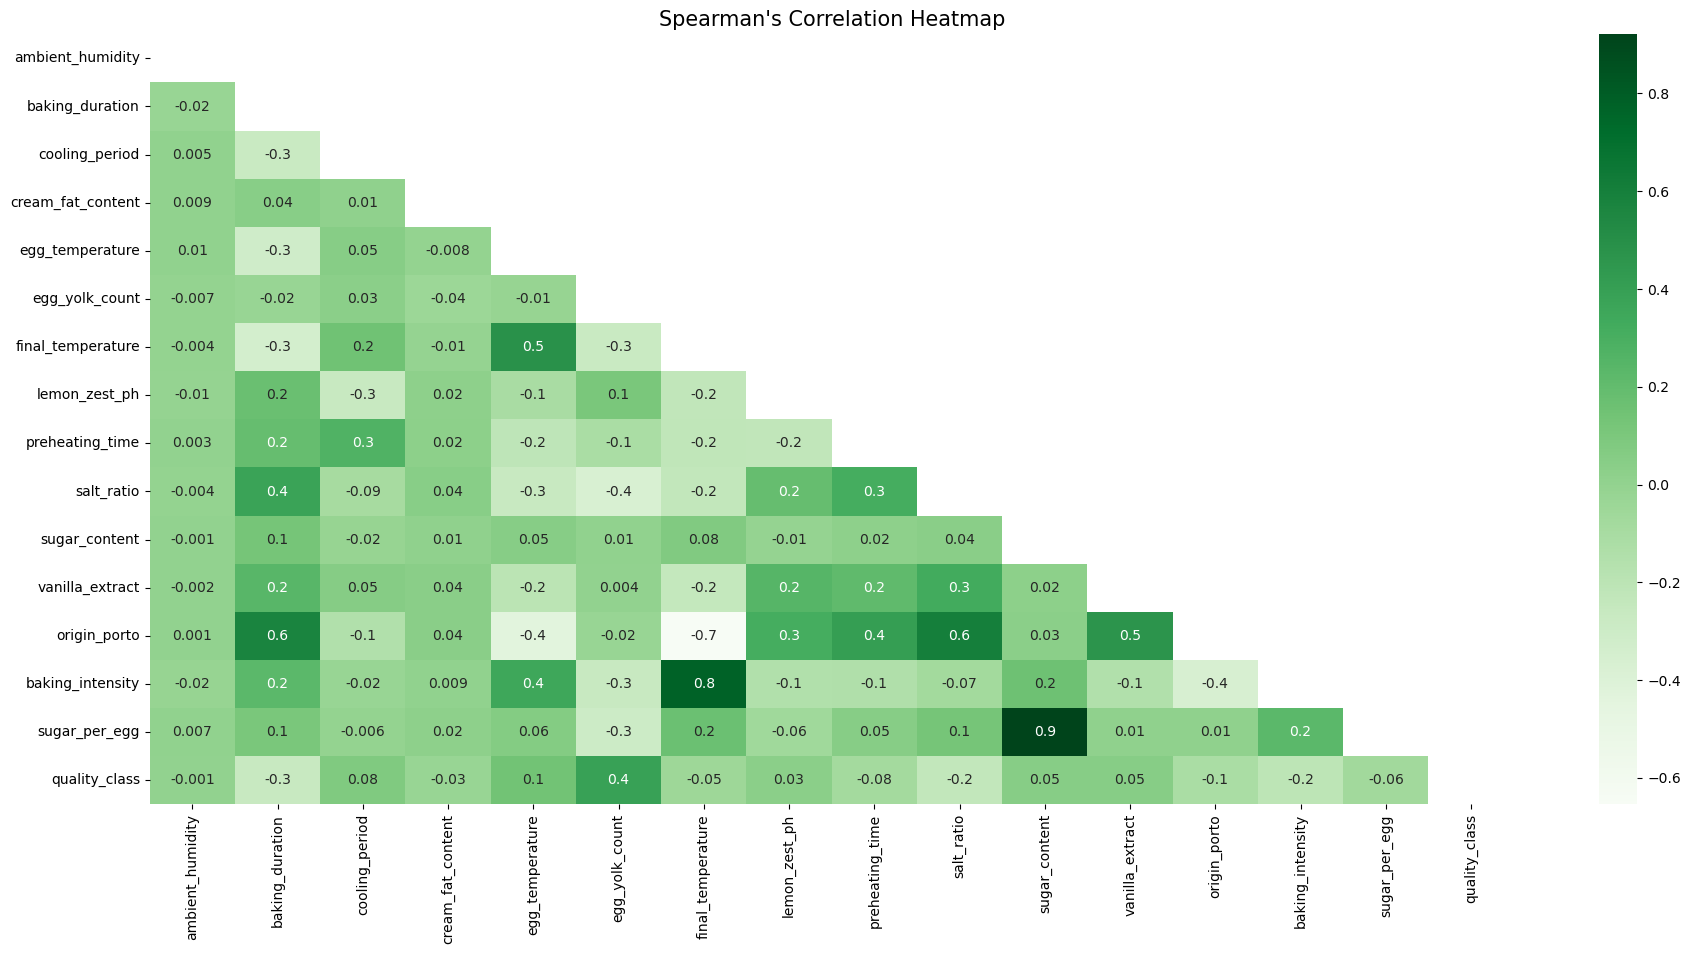

In [35]:
# Joining numerical features and target for correlation analysis
all_train = X_train_scl.join(y_train)

# Computing Spearman's Correlation
correlation = all_train.corr(method = 'spearman')

# Plotting the lower triangle of the correlation map
def corr_heatmap(correlation):
    plt.figure(figsize=(22, 10))
    ax = sns.heatmap(data = correlation, annot = True, mask = np.triu(np.ones_like(correlation)), cmap = 'Greens', fmt = '.1')
    ax.set_title("Spearman's Correlation Heatmap", fontdict = {'fontsize': 15})
    plt.show()

corr_heatmap(correlation)

<p>From here we can see that the newly created feature <code>sugar_per_egg</code> is a big step considering it's alternatives (and primary features), <code>sugar_content</code> and <code>egg_yolk_count</code>.</p>
<p>Nevertheless, the other created feature <code>baking_intensity</code> might be better than <code>final_temperature</code> given it's correlations to other features being, generally, lower.</p>

In [36]:
X_train.drop('sugar_per_egg', axis=1, inplace=True)
X_test.drop('sugar_per_egg', axis=1, inplace=True)

X_train_scl.drop('sugar_per_egg', axis=1, inplace=True)
X_test_scl.drop('sugar_per_egg', axis=1, inplace=True)

Otherwise, given the absence of strong correlations to the target feature, it's essential to apply other feature selection methods to gain deeper insights from the dataset.

<h3 style="color: #0EE071;">4.3 Wrapper methods</h3>

In this section we will apply a wrapper method for feature selection. These aim to identify the most impactful subset of features by training different predictive models with varying feature combinations and comparing their performances. We will start by initializing our model.



In [37]:
model = RandomForestClassifier()

<h4 style="color: #0EE071;">4.3.1 RFE</h4>
Recursive Feature Elimination will help selecting the most important features to keep.

In [38]:
# Number of features - 14 (1 to 15)
nof_list = np.arange(1,15)

# Variable initialization
high_score = 0 # Set the high score to zero - to track the highest accuracy found
nof = 0 # Will store the optimal number of features
score_list = [] # Stores the accuracy score for each iteration


# Loop through each potential number of features
for n in range(len(nof_list)): 
    # 1. Initialize RFE to select specifically 'nof_list[n]' features, according to the model selected - RandomForestClassifier
    rfe = RFE(model,n_features_to_select = nof_list[n])

    # 2. Fit RFE to learn importance, then reduce X_train to those top features
    X_train_rfe = rfe.fit_transform(X_train_scl,y_train)

    # 3. Reduce X_test to the SAME features (crucial to avoid LEAKEDGE)
    X_test_rfe = rfe.transform(X_test_scl)

    # 4. Retrain the model strictly on this reduced feature set
    model.fit(X_train_rfe,y_train)

    # 5. Evaluate performance on the reduced test set
    score = model.score(X_test_rfe,y_test)
    score_list.append(score)

    # 6. If this iteration beat the previous record, update the high score and the optimum number of features
    if(score > high_score):
        high_score = score
        nof = nof_list[n]

# Conclusions outputs
print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

Optimum number of features: 13
Score with 13 features: 0.787500


The optimum number of features for this method is 13. So, 13 features will be selected by the RFE model.

In [39]:
rfe = RFE(estimator = model, n_features_to_select = nof)
rfe.fit_transform(X_train_scl, y_train)
selected_features = pd.Series(rfe.support_, index = X_train_scl.columns)
print(f"Features to keep:\n{selected_features}")

Features to keep:
ambient_humidity      True
baking_duration       True
cooling_period        True
cream_fat_content     True
egg_temperature       True
egg_yolk_count        True
final_temperature     True
lemon_zest_ph         True
preheating_time       True
salt_ratio            True
sugar_content         True
vanilla_extract       True
origin_porto         False
baking_intensity      True
dtype: bool


<h3 style="color: #0EE071;">4.4 Embedded methods</h3>

We also used Embedded Methods. This technique involves selecting features during the training of predictive models, taking into account their importance.

<h4 style="color: #0EE071;">4.4.1 Lasso Regression</h4>

The following function was taken from the Machine Learning classes and serves the purpose of constructing a visualization for the feature importance.

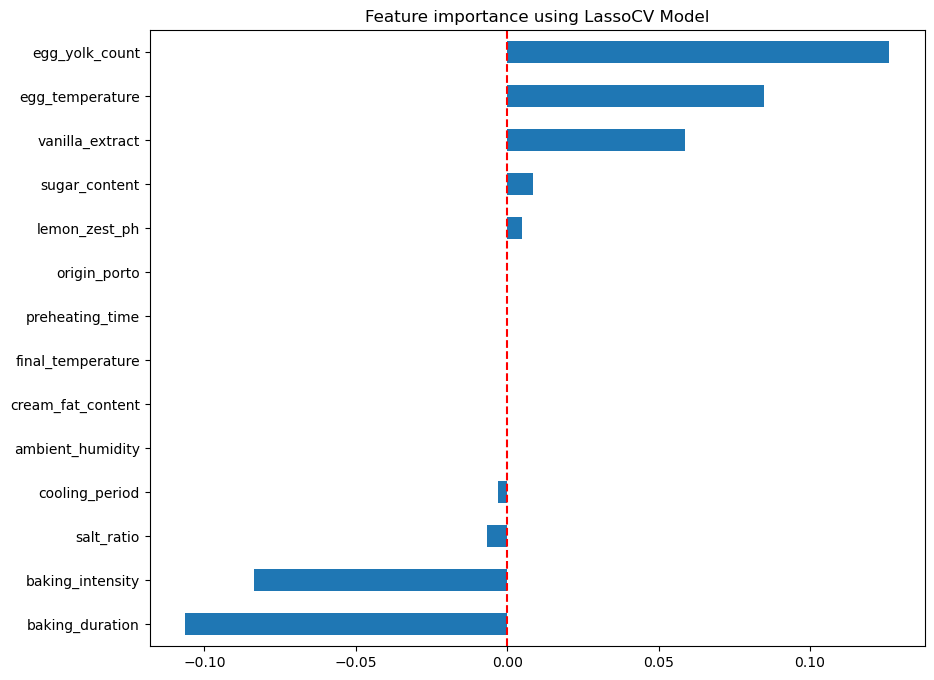

In [45]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(10,8))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()

reg = LassoCV()
reg.fit(X_train_scl, y_train)
coef = pd.Series(reg.coef_, index = X_train_scl.columns)
plot_importance(coef, 'LassoCV')

According to the Lasso Regression, we should discard the 'cream_fat_content', 'ambient_humidity' and 'origin_porto' columns, as they seem insignificant for the definition of the target when compared to the other variables. 'salt_ratio' and 'preheating time' are also on the verge of being discardable by this method.

<h4 style="color: #0EE071;">4.4.2 Decision Tree</h4>

While Lasso Regression is great for eliminating features with no linear correlation with the target, it may incorrectly discard features that are useful only in non-linear thresholds or specific combinations. 

For this, we will use a Decision Tree, to address potential ties and limit ambiguity.

Text(0.5, 1.0, 'Feature Importance using Decision Tree Classifier')

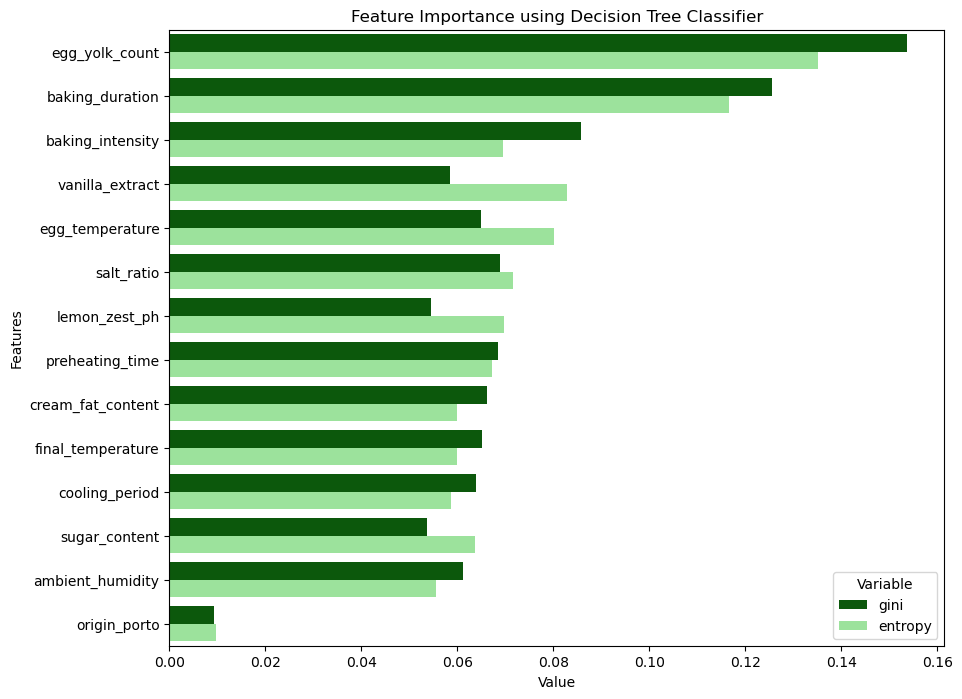

In [46]:
gini_importance = DecisionTreeClassifier(splitter='random', random_state=42).fit(X_train_scl, y_train).feature_importances_
entropy_importance = DecisionTreeClassifier(criterion='entropy', splitter='random', random_state=42).fit(X_train_scl, y_train).feature_importances_

zippy = pd.DataFrame(zip(gini_importance, entropy_importance), columns=['gini', 'entropy'])
zippy['Features'] = X_train_scl.columns
tidy = zippy.melt(id_vars='Features').rename(columns=str.title)
tidy.sort_values(['Value'], ascending=False, inplace=True)

plt.figure(figsize=(10, 8))
sns.barplot(y='Features', x='Value', hue='Variable', data=tidy, palette=['darkgreen', 'lightgreen'])
plt.title("Feature Importance using Decision Tree Classifier")

The column 'origin_porto' is clearly much less important than all other features according to this Decision Tree Classifier. By defining a threshold of 0.04 for any variable (decided by the group after looking at the results), we conclude that this classifier suggests dropping 'origin_porto' only.

Also, we have a high disparity between entropy and gini impurity in some cases, such as 'vanilla_extract' and 'baking_intensity'. Despite both being relevant for the prediction and probably none of them is being removed, we need to understand this difference. 

Entropy's preference for 'vanilla_extract' indicates that this attribute likely offers substantial "Information Gain" by effectively distinguishing a certain, probably less common, outcome that gini does not emphasize as significantly. 

'baking_intensity', on the other hand, appears to function as a strong binary threshold rather than a complex spectrum, as indicated by its higher Gini importance. Gini Impurity favors 'baking_intensity' because it is likely to create a OK/KO boundary (e.g., if preheating time is too short, the batch fails).

<h3 style="color: #0EE071;">4.5 Final Insights</h3>

| Numerical Data |  Spearman's Correlation | RFE | Lasso | Decision Tree | Relevance |
| --- | --- | --- | --- | --- | --- 
|  ambient_humidity | Discard |  Keep | Discard | Keep | **Keep*** |
|  baking_duration | Discard |  Keep  | Keep | Keep | **Keep** |
|  cooling_period | Discard  |  Keep |  Keep | Keep | **Keep** |
|  cream_fat_content | Discard  |  Keep |  Discard | Keep | **Keep*** |
|  egg_temperature  | Discard |  Keep | Keep | Keep | **Keep** |
|  egg_yolk_count  | Discard |  Keep |  Keep | Keep | **Keep** |
|  final_temperature  | Discard |  Keep | Discard | Keep | **Keep*** |
|  lemon_zest_ph  | Discard |  Keep | Keep | Keep | **Keep*** |
|  preheating_time  | Discard |  Keep |  Discard | Keep | **Keep*** |
|  salt_ratio  | Discard |  Keep |  Keep | Keep | **Keep** |
|  sugar_content  | Discard |  Keep | Keep | Keep | **Keep** |
|  vanilla_extract  | Discard |  Keep | Keep | Keep | **Keep** |
|  origin_porto  | Discard |  Discard | Discard | Discard | **Discard** |

<br>


*Given the tie in keeps and discards for these features, we decided to keep them. This is because for all these cases, only linear methods suggested to discard the features (RFE, Lasso), and as we have a classification problem, we concluded that higher priority should be given to the Decision Tree classifier, which suggested to keep these.

In [47]:
cols_to_drop = ['origin_porto']

# Dropping less important features on X_train and X_test 
X_train_final = X_train_scl.drop(cols_to_drop, axis=1)
X_test_final = X_test_scl.drop(cols_to_drop, axis=1)

# Checking the final datasets
display(X_train_final.head())
display(X_test_final.head())

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,preheating_time,salt_ratio,sugar_content,vanilla_extract,baking_intensity
893,0.45,1.444444,0.000000,0.000000,0.107143,10.0,-0.643478,0.0,2.575,2.031878,0.059524,0.764706,0.030116
1033,0.75,-0.444444,-0.285714,-0.333333,0.000000,10.0,0.478261,-0.5,0.400,0.469629,0.000000,-1.117647,0.050308
4706,-0.65,0.444444,-0.142857,0.666667,1.107143,14.0,-0.243478,0.0,-0.200,-0.603163,0.071429,0.294118,0.215606
3072,0.05,0.444444,0.428571,0.200000,-0.785714,12.0,-0.556522,0.5,-1.400,-0.884287,-1.107143,-0.705882,-0.171458
4016,0.80,1.666667,-1.071429,0.000000,-0.928571,9.0,-0.556522,0.0,0.825,1.354167,0.142857,-0.294118,0.308008


,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,preheating_time,salt_ratio,sugar_content,vanilla_extract,baking_intensity
2642,0.20,1.000000,1.928571,0.400000,0.000000,9.0,0.000000,-0.5,0.050,1.754267,0.000000,-0.529412,0.761123
2789,-0.50,0.000000,1.714286,0.000000,0.000000,9.0,1.400000,-1.5,0.450,0.409890,0.000000,0.235294,0.065024
595,0.50,-0.111111,0.428571,0.533333,0.000000,10.0,1.356522,0.0,-0.375,0.104669,0.000000,-0.294118,1.195072
2010,0.65,-0.333333,0.214286,0.666667,1.357143,12.0,-0.034783,1.0,-0.600,-0.319026,0.214286,-0.352941,-0.272416
3229,-0.65,0.888889,-2.214286,0.333333,0.035714,11.0,-0.991304,1.5,-0.725,1.512801,-0.285714,0.176471,-0.558522


Now, our datasets are ready for modeling.

<hr style = "border: 3px solid #0EE071;">
<h2 style="color: #0EE071;">5. Exports</h2>

In [ ]:
# Saving the final datasets
#X_train_final.to_pickle('Nata_files/data_clean/X_train_final.pkl')
#X_test_final.to_pickle('Nata_files/data_clean/X_test_final.pkl')  

<hr style = "border: 3px solid #0EE071;">

In [49]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Pandas version: 2.3.2
NumPy version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
Scikit-Learn version: 1.7.2
